# Predição de Diabetes com Dados NHANES 2021-2023

## 1. Carregamento e Junção dos Datasets

Carregamos os datasets do NHANES (National Health and Nutrition Examination Survey) no formato SAS (.xpt), selecionamos as colunas mais relevantes de cada um e realizamos o **LEFT JOIN** de todas as tabelas usando o identificador `SEQN` como chave, partindo da tabela demográfica (DEMO) como base.

In [2]:
import pandas as pd

# Carregar todos os datasets
demo = pd.read_sas('../datasets/DEMO_L.xpt')
bmx = pd.read_sas('../datasets/BMX_L.xpt')
bpxo = pd.read_sas('../datasets/BPXO_L.xpt')
diq = pd.read_sas('../datasets/DIQ_L.xpt')
ghb = pd.read_sas('../datasets/GHB_L.xpt')
glu = pd.read_sas('../datasets/GLU_L.xpt')
tchol = pd.read_sas('../datasets/TCHOL_L.xpt')
mcq = pd.read_sas('../datasets/MCQ_L.xpt')
paq = pd.read_sas('../datasets/PAQ_L.xpt')
smq = pd.read_sas('../datasets/SMQ_L.xpt')

# Selecionar colunas relevantes de cada dataset
demo = demo[['SEQN', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH3', 'DMDEDUC2', 'INDFMPIR', 'DMDMARTZ']]
bmx = bmx[['SEQN', 'BMXBMI', 'BMXWAIST', 'BMXWT', 'BMXHT', 'BMXHIP', 'BMXARMC']]
bpxo = bpxo[['SEQN', 'BPXOSY1', 'BPXODI1', 'BPXOSY2', 'BPXODI2', 'BPXOSY3', 'BPXODI3']]
diq = diq[['SEQN', 'DIQ010']]
ghb = ghb[['SEQN', 'LBXGH']]
glu = glu[['SEQN', 'LBXGLU']]
tchol = tchol[['SEQN', 'LBXTC']]
mcq = mcq[['SEQN', 'MCQ160A', 'MCQ160B', 'MCQ160C', 'MCQ160E', 'MCQ160F']]
paq = paq[['SEQN', 'PAD680', 'PAD800', 'PAD820']]
smq = smq[['SEQN', 'SMQ020', 'SMQ040']]

# Join de todas as tabelas usando SEQN como chave (LEFT JOIN a partir de DEMO)
df = demo.merge(bmx, on='SEQN', how='left') \
         .merge(bpxo, on='SEQN', how='left') \
         .merge(diq, on='SEQN', how='left') \
         .merge(ghb, on='SEQN', how='left') \
         .merge(glu, on='SEQN', how='left') \
         .merge(tchol, on='SEQN', how='left') \
         .merge(mcq, on='SEQN', how='left') \
         .merge(paq, on='SEQN', how='left') \
         .merge(smq, on='SEQN', how='left')

print(f'Shape após join: {df.shape}')
print(f'Colunas: {list(df.columns)}')
df.head()

Shape após join: (11933, 33)
Colunas: ['SEQN', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH3', 'DMDEDUC2', 'INDFMPIR', 'DMDMARTZ', 'BMXBMI', 'BMXWAIST', 'BMXWT', 'BMXHT', 'BMXHIP', 'BMXARMC', 'BPXOSY1', 'BPXODI1', 'BPXOSY2', 'BPXODI2', 'BPXOSY3', 'BPXODI3', 'DIQ010', 'LBXGH', 'LBXGLU', 'LBXTC', 'MCQ160A', 'MCQ160B', 'MCQ160C', 'MCQ160E', 'MCQ160F', 'PAD680', 'PAD800', 'PAD820', 'SMQ020', 'SMQ040']


,SEQN,RIAGENDR,RIDAGEYR,RIDRETH3,DMDEDUC2,INDFMPIR,DMDMARTZ,BMXBMI,BMXWAIST,BMXWT,...,MCQ160A,MCQ160B,MCQ160C,MCQ160E,MCQ160F,PAD680,PAD800,PAD820,SMQ020,SMQ040
0,130378.0,1.0,43.0,6.0,5.0,5.00,1.0,27.0,98.3,86.9,...,1.0,2.0,2.0,2.0,2.0,360.0,45.0,45.0,1.0,3.0
1,130379.0,1.0,66.0,3.0,5.0,5.00,1.0,33.5,114.7,101.8,...,2.0,2.0,2.0,2.0,2.0,480.0,45.0,45.0,1.0,3.0
2,130380.0,2.0,44.0,2.0,3.0,1.41,1.0,29.7,93.5,69.4,...,2.0,2.0,2.0,2.0,2.0,240.0,20.0,NaN,2.0,NaN
3,130381.0,2.0,5.0,7.0,NaN,1.53,NaN,23.8,70.4,34.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130382.0,1.0,2.0,3.0,NaN,3.60,NaN,NaN,NaN,13.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Criação da Variável Target

Construímos a variável `DIABETES` (0 ou 1) combinando três critérios diagnósticos da **ADA (American Diabetes Association)**:
- **Critério A:** `DIQ010 == 1` → médico informou que o paciente tem diabetes
- **Critério B:** `LBXGH >= 6.5` → hemoglobina glicada (HbA1c) elevada
- **Critério C:** `LBXGLU >= 126` → glicemia de jejum ≥ 126 mg/dL

Após criar o target, removemos as colunas diagnósticas para evitar **data leakage** e filtramos apenas adultos (≥ 18 anos).

In [3]:
# Criar variável target combinando os 3 critérios diagnósticos da ADA:
# A) DIQ010 == 1 → médico disse que tem diabetes
# B) LBXGH >= 6.5 → HbA1c elevada
# C) LBXGLU >= 126 → glicemia de jejum elevada
df['DIABETES'] = (
    (df['DIQ010'] == 1) |
    (df['LBXGH'] >= 6.5) |
    (df['LBXGLU'] >= 126)
).astype(int)

# Remover linhas sem nenhuma informação para definir o target
# (precisa ter pelo menos um dos 3 critérios preenchido)
mask_target = df['DIQ010'].notna() | df['LBXGH'].notna() | df['LBXGLU'].notna()
df = df[mask_target]

# Remover colunas usadas no target (evitar data leakage)
df = df.drop(columns=['DIQ010', 'LBXGH', 'LBXGLU'])

# Filtrar apenas adultos (>= 18 anos)
df = df[df['RIDAGEYR'] >= 18]

print(f'Shape final: {df.shape}')
print(f'\nDistribuição do target:')
print(df['DIABETES'].value_counts())
print(f'\nProporção: {df["DIABETES"].mean():.2%} diabéticos')

Shape final: (8150, 31)

Distribuição do target:
DIABETES
0    6844
1    1306
Name: count, dtype: int64

Proporção: 16.02% diabéticos


## 3. Limpeza de Códigos Especiais

O NHANES utiliza códigos numéricos para respostas de **recusa** (7, 77, 7777) e **"não sabe"** (9, 99, 9999) nos questionários. Esses valores não representam dados reais e precisam ser substituídos por `NaN` para não distorcer o modelo — por exemplo, sem esse tratamento, "7777 minutos sentado por dia" seria interpretado como um valor real.

In [4]:
# Substituir códigos de recusa (7/77/7777) e não sabe (9/99/9999) por NaN
import numpy as np

refusal_codes = {
    # Questionário - códigos 7=Refused, 9=Don't know
    'DMDEDUC2': [7, 9],
    'DMDMARTZ': [77, 99],
    'MCQ160A': [7, 9],
    'MCQ160B': [7, 9],
    'MCQ160C': [7, 9],
    'MCQ160E': [7, 9],
    'MCQ160F': [7, 9],
    'SMQ020': [7, 9],
    'SMQ040': [7, 9],
    # Atividade física - códigos 7777=Refused, 9999=Don't know
    'PAD680': [7777, 9999],
    'PAD800': [7777, 9999],
    'PAD820': [7777, 9999],
}

replaced = 0
for col, codes in refusal_codes.items():
    if col in df.columns:
        mask = df[col].isin(codes)
        replaced += mask.sum()
        df.loc[mask, col] = np.nan

print(f'Total de valores substituídos por NaN: {replaced}')
print(f'Shape: {df.shape}')

Total de valores substituídos por NaN: 242
Shape: (8150, 31)


## 4. Análise de Valores Ausentes

Verificamos o percentual de valores ausentes em cada coluna para entender a qualidade dos dados antes de prosseguir com o pré-processamento.

In [5]:
# Percentual de missing por coluna
missing = df.isnull().mean().sort_values(ascending=False) * 100
print('Missing values (%):\n')
for col, pct in missing.items():
    bar = '█' * int(pct // 2)
    print(f'{col:12s} {pct:6.1f}%  {bar}')

Missing values (%):

SMQ040         60.2%  ██████████████████████████████
PAD820         54.9%  ███████████████████████████
LBXTC          29.9%  ██████████████
BMXHIP         26.9%  █████████████
BMXWAIST       26.1%  █████████████
BPXODI3        25.1%  ████████████
BPXOSY3        25.1%  ████████████
BPXODI2        25.0%  ████████████
BPXOSY2        25.0%  ████████████
BPXODI1        24.9%  ████████████
BPXOSY1        24.9%  ████████████
BMXARMC        24.5%  ████████████
BMXBMI         23.5%  ███████████
BMXWT          23.3%  ███████████
BMXHT          23.2%  ███████████
PAD800         21.8%  ██████████
INDFMPIR       17.0%  ████████
MCQ160C         4.6%  ██
DMDMARTZ        4.5%  ██
DMDEDUC2        4.5%  ██
MCQ160F         4.5%  ██
MCQ160A         4.4%  ██
MCQ160B         4.4%  ██
MCQ160E         4.4%  ██
PAD680          1.0%  
SMQ020          0.4%  
RIDRETH3        0.0%  
RIDAGEYR        0.0%  
RIAGENDR        0.0%  
SEQN            0.0%  
DIABETES        0.0%  


## 5. Feature Engineering

Realizamos três transformações:
- **`SMQ040`**: Preenchemos os `NaN` com 0 (significa "nunca fumou"), pois essa pergunta só é feita a quem já fumou 100+ cigarros (`SMQ020 == 1`).
- **Pressão arterial**: Consolidamos as 3 medições de pressão sistólica e diastólica em uma única média por pessoa, reduzindo 6 colunas para 2 (`BP_SYS` e `BP_DIA`).
- **`SEQN`**: Removido por ser apenas um identificador, sem valor preditivo.

In [6]:
# Tratar SMQ040: NaN = nunca fumou (quem respondeu SMQ020=2 não recebe SMQ040)
df['SMQ040'] = df['SMQ040'].fillna(0)

# Feature engineering: média das 3 medições de pressão
df['BP_SYS'] = df[['BPXOSY1', 'BPXOSY2', 'BPXOSY3']].mean(axis=1)
df['BP_DIA'] = df[['BPXODI1', 'BPXODI2', 'BPXODI3']].mean(axis=1)
df = df.drop(columns=['BPXOSY1', 'BPXOSY2', 'BPXOSY3', 'BPXODI1', 'BPXODI2', 'BPXODI3'])

# Remover SEQN (identificador, não é feature)
df = df.drop(columns=['SEQN'])

print(f'Shape: {df.shape}')
print(f'Colunas: {list(df.columns)}')

Shape: (8150, 26)
Colunas: ['RIAGENDR', 'RIDAGEYR', 'RIDRETH3', 'DMDEDUC2', 'INDFMPIR', 'DMDMARTZ', 'BMXBMI', 'BMXWAIST', 'BMXWT', 'BMXHT', 'BMXHIP', 'BMXARMC', 'LBXTC', 'MCQ160A', 'MCQ160B', 'MCQ160C', 'MCQ160E', 'MCQ160F', 'PAD680', 'PAD800', 'PAD820', 'SMQ020', 'SMQ040', 'DIABETES', 'BP_SYS', 'BP_DIA']


## 6. Matriz de Correlação

Analisamos a correlação de Pearson entre todas as variáveis para identificar:
- Quais features têm maior **relação linear** com a variável target (`DIABETES`)
- Possíveis problemas de **multicolinearidade** entre features (ex: IMC, cintura, peso e quadril são altamente correlacionados entre si)

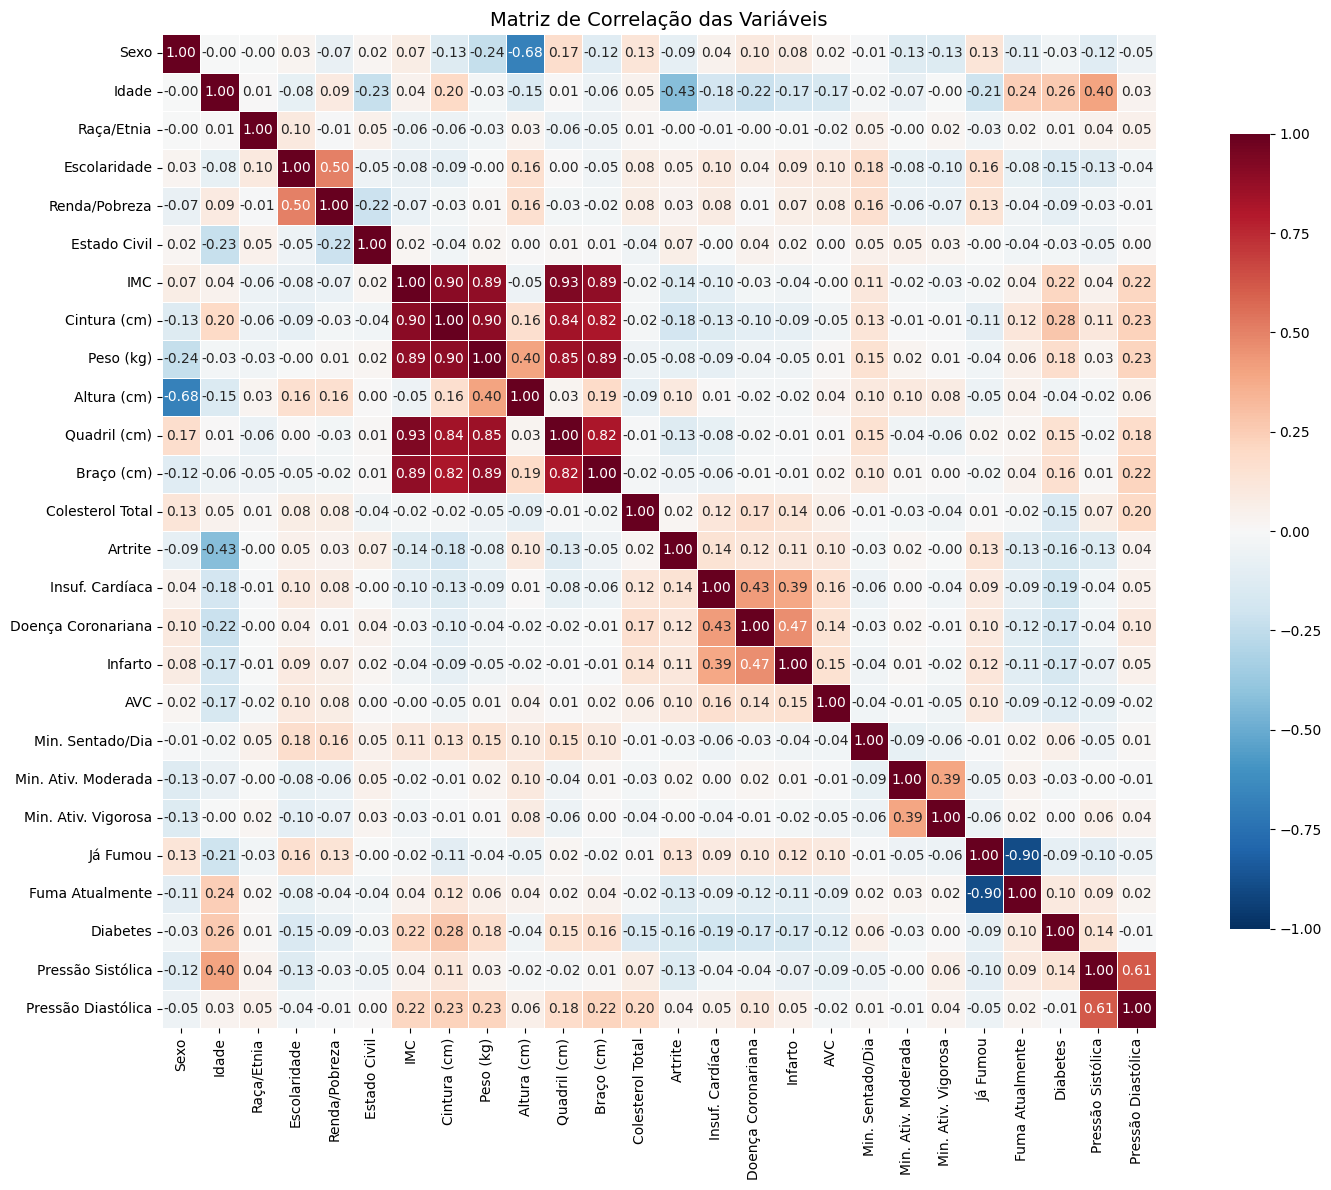


Correlação com Diabetes (ordenada):

Cintura (cm)           +0.277  ███████████
Idade                  +0.258  ██████████
IMC                    +0.215  ████████
Insuf. Cardíaca        -0.190  ███████
Peso (kg)              +0.178  ███████
Doença Coronariana     -0.172  ██████
Infarto                -0.170  ██████
Braço (cm)             +0.162  ██████
Artrite                -0.160  ██████
Escolaridade           -0.153  ██████
Quadril (cm)           +0.153  ██████
Colesterol Total       -0.153  ██████
Pressão Sistólica      +0.137  █████
AVC                    -0.122  ████
Fuma Atualmente        +0.098  ███
Já Fumou               -0.091  ███
Renda/Pobreza          -0.088  ███
Min. Sentado/Dia       +0.058  ██
Altura (cm)            -0.044  █
Sexo                   -0.034  █
Min. Ativ. Moderada    -0.029  █
Estado Civil           -0.027  █
Raça/Etnia             +0.014  
Pressão Diastólica     -0.009  
Min. Ativ. Vigorosa    +0.002  


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dicionário de nomes legíveis para cada coluna
col_labels = {
    'RIAGENDR': 'Sexo',
    'RIDAGEYR': 'Idade',
    'RIDRETH3': 'Raça/Etnia',
    'DMDEDUC2': 'Escolaridade',
    'INDFMPIR': 'Renda/Pobreza',
    'DMDMARTZ': 'Estado Civil',
    'BMXBMI': 'IMC',
    'BMXWAIST': 'Cintura (cm)',
    'BMXWT': 'Peso (kg)',
    'BMXHT': 'Altura (cm)',
    'BMXHIP': 'Quadril (cm)',
    'BMXARMC': 'Braço (cm)',
    'LBXTC': 'Colesterol Total',
    'MCQ160A': 'Artrite',
    'MCQ160B': 'Insuf. Cardíaca',
    'MCQ160C': 'Doença Coronariana',
    'MCQ160E': 'Infarto',
    'MCQ160F': 'AVC',
    'PAD680': 'Min. Sentado/Dia',
    'PAD800': 'Min. Ativ. Moderada',
    'PAD820': 'Min. Ativ. Vigorosa',
    'SMQ020': 'Já Fumou',
    'SMQ040': 'Fuma Atualmente',
    'BP_SYS': 'Pressão Sistólica',
    'BP_DIA': 'Pressão Diastólica',
    'DIABETES': 'Diabetes',
}

# Renomear colunas para exibição
df_display = df.rename(columns=col_labels)
corr = df_display.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlação das Variáveis', fontsize=14)
plt.tight_layout()
plt.show()

# Correlação com o target (DIABETES), ordenada
print('\nCorrelação com Diabetes (ordenada):\n')
corr_target = corr['Diabetes'].drop('Diabetes').sort_values(key=abs, ascending=False)
for feat, val in corr_target.items():
    bar = '█' * int(abs(val) * 40)
    sign = '+' if val > 0 else '-'
    print(f'{feat:22s} {sign}{abs(val):.3f}  {bar}')

## 7. Pré-processamento

Definimos os pipelines de pré-processamento usando `ColumnTransformer`:
- **Variáveis contínuas**: imputação pela mediana + padronização (`StandardScaler`)
- **Variáveis categóricas**: imputação pela moda (`most_frequent`)

O `StandardScaler` é necessário para a Logistic Regression, pois ela é sensível à escala das features.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Separar features e target
X = df.drop(columns=['DIABETES'])
y = df['DIABETES']

# Identificar colunas contínuas e categóricas
continuous_cols = ['RIDAGEYR', 'INDFMPIR', 'BMXBMI', 'BMXWAIST', 'BMXWT', 'BMXHT',
                   'BMXHIP', 'BMXARMC', 'LBXTC', 'PAD680', 'PAD800', 'PAD820',
                   'BP_SYS', 'BP_DIA']
categorical_cols = ['RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'DMDMARTZ',
                    'MCQ160A', 'MCQ160B', 'MCQ160C', 'MCQ160E', 'MCQ160F',
                    'SMQ020', 'SMQ040']

# Pipelines de pré-processamento
continuous_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer([
    ('num', continuous_pipeline, continuous_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

print(f'Features contínuas ({len(continuous_cols)}): {continuous_cols}')
print(f'Features categóricas ({len(categorical_cols)}): {categorical_cols}')

Features contínuas (14): ['RIDAGEYR', 'INDFMPIR', 'BMXBMI', 'BMXWAIST', 'BMXWT', 'BMXHT', 'BMXHIP', 'BMXARMC', 'LBXTC', 'PAD680', 'PAD800', 'PAD820', 'BP_SYS', 'BP_DIA']
Features categóricas (11): ['RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'DMDMARTZ', 'MCQ160A', 'MCQ160B', 'MCQ160C', 'MCQ160E', 'MCQ160F', 'SMQ020', 'SMQ040']


## 8. Split dos Dados

Dividimos o dataset em treino (80%) e teste (20%) usando **split estratificado** — garante que a proporção de diabéticos seja mantida igualmente em ambos os conjuntos, evitando viés no processo de avaliação.

In [9]:
# Split estratificado para manter a proporção do target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras ({y_train.mean():.2%} diabéticos)')
print(f'Teste:  {X_test.shape[0]} amostras ({y_test.mean():.2%} diabéticos)')

Treino: 6520 amostras (16.03% diabéticos)
Teste:  1630 amostras (16.01% diabéticos)


## 9. KNN — Escolha do K Ótimo (Curva de Validação)

O valor de **K** (número de vizinhos) é o principal hiperparâmetro do KNN. Um K muito pequeno causa overfitting; um K muito grande suaviza demais as fronteiras de decisão.

Testamos K ímpares de 1 a 30 usando **validação cruzada (5-fold)** com AUC-ROC como métrica — técnica chamada de **Curva de Validação do K**. Diferente do Elbow Method do K-Means (que usa inércia em aprendizado não supervisionado), aqui temos rótulos reais, então basta escolher o K com maior AUC.

Melhor K: 29  |  AUC-ROC médio: 0.7677


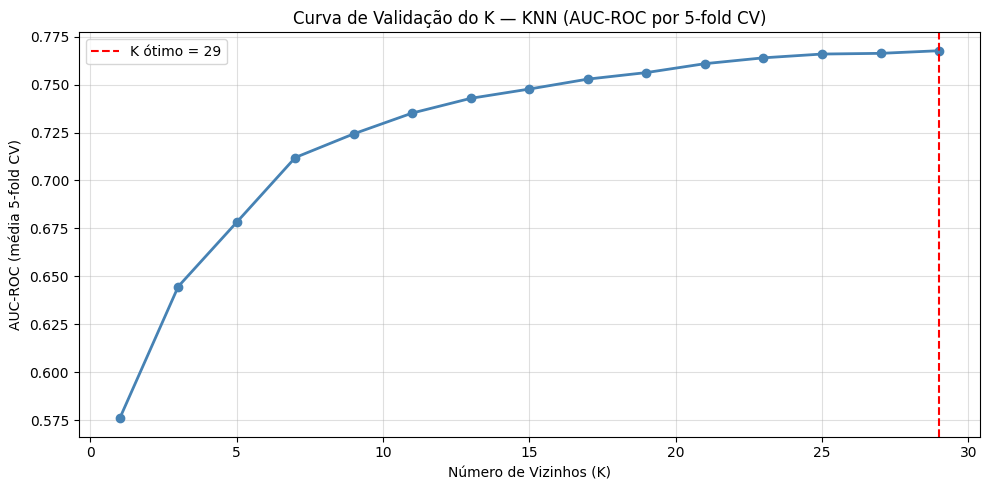

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# Testar K ímpares de 1 a 30 (ímpares evitam empates na decisão)
k_range = range(1, 31, 2)
auc_scores = []

for k in k_range:
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')
    auc_scores.append(scores.mean())

best_k = list(k_range)[int(np.argmax(auc_scores))]
print(f'Melhor K: {best_k}  |  AUC-ROC médio: {max(auc_scores):.4f}')

# Curva de Validação do K
plt.figure(figsize=(10, 5))
plt.plot(list(k_range), auc_scores, marker='o', linewidth=2, color='steelblue')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'K ótimo = {best_k}')
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('AUC-ROC (média 5-fold CV)')
plt.title('Curva de Validação do K — KNN (AUC-ROC por 5-fold CV)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [11]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=best_k, weights='distance', n_jobs=-1))
])
knn_pipeline.fit(X_train, y_train)
y_pred_knn = knn_pipeline.predict(X_test)
y_prob_knn = knn_pipeline.predict_proba(X_test)[:, 1]

print(f'KNN treinado com K={best_k}.')

KNN treinado com K=29.


## 10. Treinamento — SVM Linear (LinearSVC)

Versão linear do SVM, mais eficiente computacionalmente que o kernel RBF. Como `LinearSVC` não suporta `predict_proba` diretamente, usamos `CalibratedClassifierCV` para estimar probabilidades via validação cruzada — necessário para o cálculo do AUC-ROC.

In [12]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', CalibratedClassifierCV(
        LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)
    ))
])
svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)
y_prob_svm = svm_pipeline.predict_proba(X_test)[:, 1]

print('SVM Linear treinado com sucesso.')

SVM Linear treinado com sucesso.


## 11. Treinamento — Logistic Regression

Modelo linear com `class_weight='balanced'` para compensar o desbalanceamento. Usa todas as features pré-processadas pelo pipeline definido na etapa 7.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print('Logistic Regression treinada com sucesso.')

Logistic Regression treinada com sucesso.


## 12. Treinamento — Random Forest

Modelo ensemble baseado em árvores de decisão com `class_weight='balanced'` e 200 estimadores. Captura relações não-lineares e é robusto a outliers.

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
    ))
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print('Random Forest treinado com sucesso.')

Random Forest treinado com sucesso.


## 13. Avaliação Comparativa dos Modelos

Comparamos os modelos usando **classification report** (precision, recall, F1-score) e **AUC-ROC**.

> **Recall** é a métrica mais importante neste contexto clínico: é pior deixar de identificar um diabético (falso negativo) do que classificar erroneamente um não-diabético (falso positivo).

In [15]:
from sklearn.metrics import classification_report, roc_auc_score

modelos = [
    (f'KNN (k={best_k})',       y_pred_knn, y_prob_knn),
    ('SVM LINEAR',             y_pred_svm, y_prob_svm),
    ('LOGISTIC REGRESSION',    y_pred_lr,  y_prob_lr),
    ('RANDOM FOREST',          y_pred_rf,  y_prob_rf),
]

for nome, y_pred, y_prob in modelos:
    print('=' * 50)
    print(nome)
    print('=' * 50)
    print(classification_report(y_test, y_pred, target_names=['Não Diabético', 'Diabético']))
    print(f'AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}\n')

KNN (k=29)
               precision    recall  f1-score   support

Não Diabético       0.84      1.00      0.91      1369
    Diabético       0.40      0.02      0.03       261

     accuracy                           0.84      1630
    macro avg       0.62      0.51      0.47      1630
 weighted avg       0.77      0.84      0.77      1630

AUC-ROC: 0.7538

SVM LINEAR
               precision    recall  f1-score   support

Não Diabético       0.86      0.97      0.91      1369
    Diabético       0.55      0.19      0.28       261

     accuracy                           0.85      1630
    macro avg       0.71      0.58      0.60      1630
 weighted avg       0.81      0.85      0.81      1630

AUC-ROC: 0.8118

LOGISTIC REGRESSION
               precision    recall  f1-score   support

Não Diabético       0.94      0.71      0.81      1369
    Diabético       0.33      0.76      0.46       261

     accuracy                           0.72      1630
    macro avg       0.64      0.74  

## Validação Cruzada dos Modelos

Foi aplicada validação cruzada estratificada (5-fold) para obter uma estimativa mais robusta do desempenho dos modelos.

In [16]:

from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

modelos_cv = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "SVM Linear": svm_pipeline,
    f"KNN (k={best_k})": knn_pipeline
}

resultados_cv = []

for nome, modelo in modelos_cv.items():
    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    resultados_cv.append({
        "Modelo": nome,
        "Accuracy CV Mean": scores["test_accuracy"].mean(),
        "Recall CV Mean": scores["test_recall"].mean(),
        "F1 CV Mean": scores["test_f1"].mean(),
        "ROC AUC CV Mean": scores["test_roc_auc"].mean()
    })

df_resultados_cv = pd.DataFrame(resultados_cv).sort_values(by="Recall CV Mean", ascending=False)
df_resultados_cv


,Modelo,Accuracy CV Mean,Recall CV Mean,F1 CV Mean,ROC AUC CV Mean
0,Logistic Regression,0.726227,0.733014,0.462303,0.808390
2,SVM Linear,0.848466,0.192344,0.288417,0.807915
1,Random Forest,0.846319,0.106220,0.181290,0.811331
3,KNN (k=29),0.841564,0.022967,0.044311,0.773256


## Interpretação do Modelo com Feature Importance

O Random Forest foi utilizado para identificar as variáveis mais relevantes para a classificação.

,label,importance
0,Idade (anos),0.156397
3,Circunf. Cintura (cm),0.083417
8,Colesterol Total (mg/dL),0.072062
2,IMC,0.060167
1,Razão Renda/Pobreza,0.057446
9,Tempo Sedentário (min/dia),0.049906
12,Pressão Sistólica (mmHg),0.048833
4,Peso (kg),0.046748
6,Circunf. Quadril (cm),0.046218
13,Pressão Diastólica (mmHg),0.046141


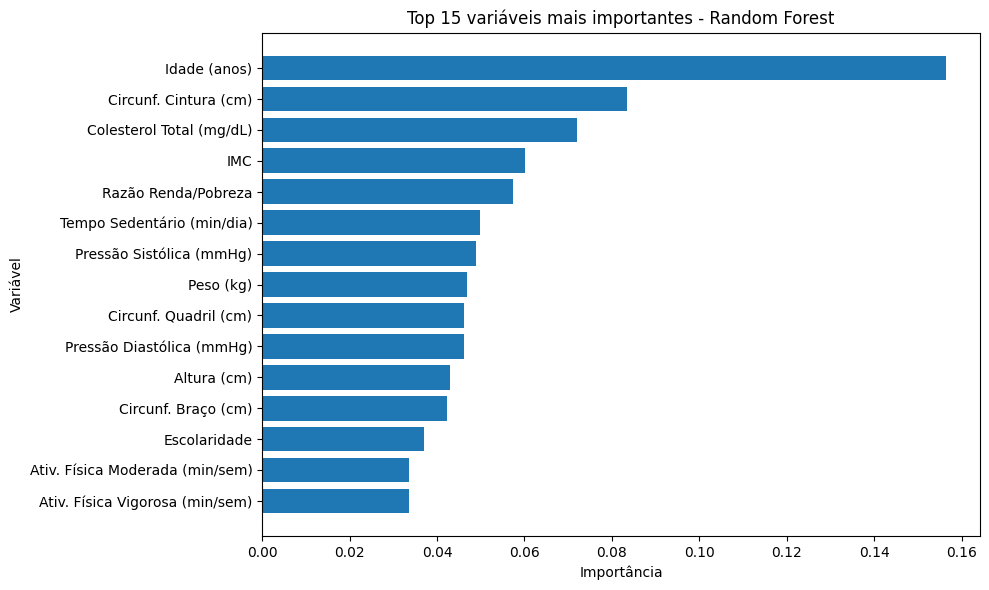

In [17]:

import pandas as pd
import matplotlib.pyplot as plt

rf_model = rf_pipeline.named_steps["classifier"]
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_model.feature_importances_

# Mapeamento de nomes tecnicos para rotulos legiveis
feature_labels = {
    "num__RIDAGEYR": "Idade (anos)",
    "num__INDFMPIR": "Razão Renda/Pobreza",
    "num__BMXBMI": "IMC",
    "num__BMXWAIST": "Circunf. Cintura (cm)",
    "num__BMXWT": "Peso (kg)",
    "num__BMXHT": "Altura (cm)",
    "num__BMXHIP": "Circunf. Quadril (cm)",
    "num__BMXARMC": "Circunf. Braço (cm)",
    "num__LBXTC": "Colesterol Total (mg/dL)",
    "num__PAD680": "Tempo Sedentário (min/dia)",
    "num__PAD800": "Ativ. Física Vigorosa (min/sem)",
    "num__PAD820": "Ativ. Física Moderada (min/sem)",
    "num__BP_SYS": "Pressão Sistólica (mmHg)",
    "num__BP_DIA": "Pressão Diastólica (mmHg)",
    "cat__RIAGENDR": "Sexo",
    "cat__RIDRETH3": "Raça/Etnia",
    "cat__DMDEDUC2": "Escolaridade",
    "cat__DMDMARTZ": "Estado Civil",
    "cat__MCQ160A": "Artrite",
    "cat__MCQ160B": "Insuf. Cardíaca Congestiva",
    "cat__MCQ160C": "Doença Coronariana",
    "cat__MCQ160E": "Ataque Cardíaco",
    "cat__MCQ160F": "AVC",
    "cat__SMQ020": "Já Fumou",
    "cat__SMQ040": "Fuma Atualmente",
}

df_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

df_importance["label"] = df_importance["feature"].map(feature_labels).fillna(df_importance["feature"])

display(df_importance[["label", "importance"]].head(15))

plt.figure(figsize=(10, 6))
plt.barh(df_importance["label"].head(15)[::-1], df_importance["importance"].head(15)[::-1])
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.title("Top 15 variáveis mais importantes - Random Forest")
plt.tight_layout()
plt.show()


## Curva ROC dos Modelos

A curva ROC foi utilizada para comparar a capacidade discriminativa dos modelos em diferentes limiares.

<Figure size 800x600 with 0 Axes>

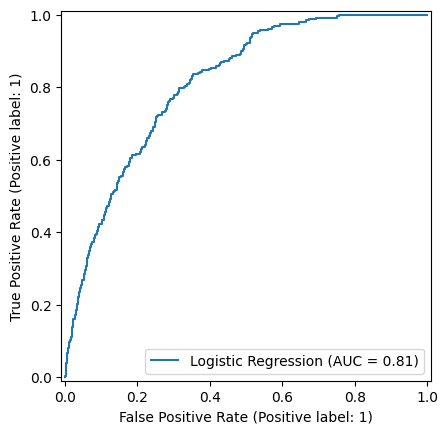

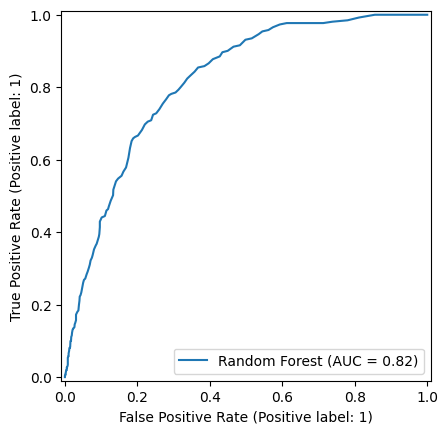

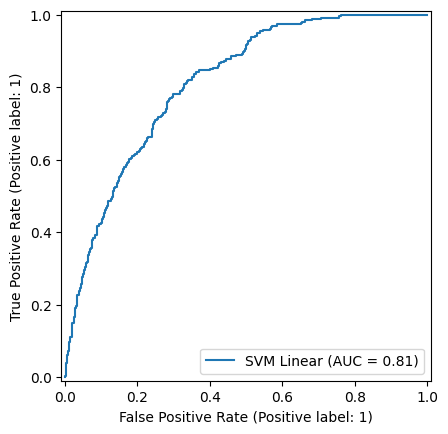

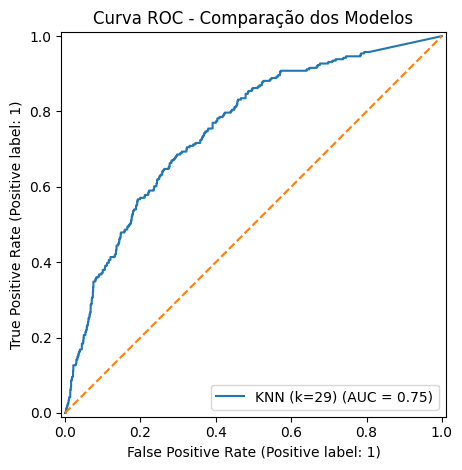

In [18]:

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

modelos_plot = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "SVM Linear": svm_pipeline,
    f"KNN (k={best_k})": knn_pipeline
}

plt.figure(figsize=(8, 6))

for nome, modelo in modelos_plot.items():
    RocCurveDisplay.from_estimator(modelo, X_test, y_test, name=nome)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC - Comparação dos Modelos")
plt.tight_layout()
plt.show()


## Matriz de Confusão do Melhor Modelo

A matriz de confusão foi utilizada para analisar os acertos e erros do modelo (Logistic Regression) na classificaç

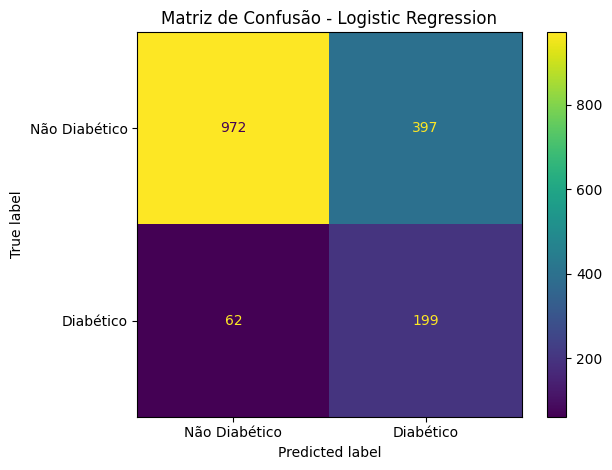

In [19]:

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    lr_pipeline,
    X_test,
    y_test,
    display_labels=["Não Diabético", "Diabético"]
)
plt.title("Matriz de Confusão - Logistic Regression")
plt.tight_layout()
plt.show()
